<a href="https://colab.research.google.com/github/PozieSwagger/lis4693-final-project/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LIS 4963: Final Project

## Task 1: Install and Import
Installing the required packages and import the csv file from the GitHub Repo.

In [34]:
!pip install gensim
!pip install pyldavis
!pip install nltk
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [28]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import gensim.corpora as corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()
import re
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
import pandas as pd
import requests
import io

url = "https://raw.githubusercontent.com/PozieSwagger/lis4693-final-project/refs/heads/main/youtube.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

## Task 2: Text preprocessing and analysis
Checking the data through displaying the first 10 rows and selecting what column that would be used throughout the project.

Reasoning for selecting the 'description' column for text analysis, orginated as 'title' has very simple titles that give no clear information relating to what was within the Superbowl Ad besides company name and dates. The 'description' column provide more information to analysis that can connect to understand what a Superbowl Ad message was orginially, far from simple company names or dates.

In [25]:
df = pd.read_csv(io.StringIO(text))
# Add index for sential analysis
df['index'] = df.index
print(df.head(10))

# Create varibles for both text analysis
topic_Modeling = df['description']
sential_analysis = df[['index','description']].copy()
print(topic_Modeling.head())
print(sential_analysis.head())

   year      brand                          superbowl_ads_dot_com_url  \
0  2018     Toyota        https://superbowl-ads.com/good-odds-toyota/   
1  2020  Bud Light  https://superbowl-ads.com/2020-bud-light-seltz...   
2  2006  Bud Light  https://superbowl-ads.com/2006-bud-light-bear-...   
3  2018    Hynudai  https://superbowl-ads.com/hope-detector-nfl-su...   
4  2003  Bud Light  https://superbowl-ads.com/2003-bud-light-hermi...   
5  2020     Toyota  https://superbowl-ads.com/2020-toyota-go-place...   
6  2020  Coca-Cola  https://superbowl-ads.com/2020-coca-cola-energ...   
7  2020        Kia  https://superbowl-ads.com/2020-kia-tough-never...   
8  2020    Hynudai  https://superbowl-ads.com/2020-hyundai-smaht-p...   
9  2020  Budweiser  https://superbowl-ads.com/2020-budweiser-typic...   

                                   youtube_url  funny  show_product_quickly  \
0  https://www.youtube.com/watch?v=zeBZvwYQ-hA  False                 False   
1  https://www.youtube.com/watch?v=nbb

In [9]:
# Initialize lemmatizer and stopwords
stop_words = stopwords.words('english')
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Deal with issue of NaN
    if not isinstance(text, str):
        return []

    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z]', ' ', text)
    words = text.split()

    # Remove stopwords
    processed_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words and len(word) > 2]
    return processed_words

### Topic Modeling
Work through first Topic Modeling for the first text analysis being used.

In [12]:
# Adding custom stopwords
custom_stopwords = ['http', 'https', 'www', 'com', 'youtube', 'advertiser', 'aired', 'channel', 'commercial']
stop_words.extend(custom_stopwords)

# Apply preprocessing to the 'description' column
topic_processed_data = [preprocess_text(doc) for doc in topic_Modeling]
dictionary = corpora.Dictionary(topic_processed_data)
corpus = [dictionary.doc2bow(doc) for doc in topic_processed_data]

print("Preprocessing complete. Dictionary and Corpus created.")
print(f"Number of unique tokens: {len(dictionary)}")
print(f"Number of documents in corpus: {len(corpus)}")

print("Viewing bag-of-words")
for num in corpus[0]:
    num = num[0]
    print(f"{num}\t{dictionary[num]}")

Preprocessing complete. Dictionary and Corpus created.
Number of unique tokens: 2096
Number of documents in corpus: 247
Viewing bag-of-words
0	almost
1	awtezreup
2	beat
3	billion
4	bowl
5	eight
6	film
7	follows
8	gold
9	good
10	hziq
11	journey
12	lauren
13	medal
14	named
15	odds
16	one
17	paralympic
18	super
19	toyot
20	toyota
21	uchzgob
22	watch
23	win
24	winning
25	woolstencroft


Running LDA models for the 20 topics

In [21]:
# LDA for 20 topics
print("Running LDA model with 20 topics...")
lda_model_20_topics = LdaModel(corpus=corpus, id2word=dictionary, num_topics=20, random_state=100, update_every=1, chunksize=100, passes=10, alpha='auto', per_word_topics=True)

# Analyze resulting LDA model for 20
print("LDA Model Topics with ID, Score, and word distribution:")
for topic_id, topic_words in lda_model_20_topics.print_topics():
    print(f"Topic ID: {topic_id}")
    print(f"Topic Words: {topic_words}\n")

Running LDA model with 20 topics...
LDA Model Topics with ID, Score, and word distribution:
Topic ID: 0
Topic Words: 0.115*"nfl" + 0.026*"watch" + 0.026*"game" + 0.022*"favorite" + 0.022*"fantasy" + 0.016*"instagram" + 0.016*"check" + 0.016*"free" + 0.015*"team" + 0.015*"twitter"

Topic ID: 1
Topic Words: 0.137*"super" + 0.136*"bowl" + 0.044*"light" + 0.043*"bud" + 0.043*"commercial" + 0.026*"ad" + 0.025*"fails" + 0.025*"funny" + 0.023*"best" + 0.022*"budweiser"

Topic ID: 2
Topic Words: 0.035*"music" + 0.018*"client" + 0.012*"crown" + 0.012*"black" + 0.012*"york" + 0.008*"agency" + 0.006*"production" + 0.005*"house" + 0.005*"doll" + 0.005*"soho"

Topic ID: 3
Topic Words: 0.067*"kia" + 0.042*"toyota" + 0.036*"one" + 0.033*"new" + 0.027*"right" + 0.025*"american" + 0.024*"back" + 0.023*"car" + 0.021*"game" + 0.019*"jacob"

Topic ID: 4
Topic Words: 0.028*"two" + 0.023*"baby" + 0.021*"day" + 0.021*"party" + 0.020*"feature" + 0.020*"anheuser" + 0.020*"busch" + 0.020*"sport" + 0.017*"love" 

### Sential Analysis

For this next set of code, it would be working through sential analysis.

In [31]:
# Apply preprocessing to the 'description' column
sential_analysis['description'] = sential_analysis['description'].str.casefold()
sential_analysis['description'] = sential_analysis['description'].fillna('')
sential_analysis['description'] = sential_analysis['description'].str.replace("[^a-z]", " ")

In [32]:
df1 = pd.DataFrame()
df1['Index'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in sential_analysis.iterrows():
    scores = sid.polarity_scores(row['description']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'index': row['index'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

Processing sentiment analysis...


In [33]:
# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

    index sentiment_type  sentiment_score
3       0       compound           0.9887
7       1       compound           0.9468
11      2       compound           0.5994
15      3       compound           0.3182
19      4       compound           0.0000
23      5       compound           0.9712
27      6       compound          -0.1012
31      7       compound          -0.9080
35      8       compound           0.0000
39      9       compound           0.0000


## Task 3: Machine Learning


### Set up
create the dataframe for the machine learning and set target names from Youtubes builtin category id system.

In [78]:
features = df['description']
target = df['category_id']
target_names = {
    'Film & Animation' : '1',
    'Autos & Vehicles' : '2',
    'Music' : '10',
    'Sports' : '17',
    'People & Blogs' : '22',
    'Comedy' : '23',
    'Entertainment' : '24',
    'Education' : '27'
}

 ### Classifiers
 Going through the steps of choosing the best classifier for the dataset. Along the ways there were issues with NaN and parts where sections would have empty srings from dealing with NaN, but that was resolve through some trick to modify those rows that don't have nuymeric values.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

In [83]:
# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

# Remove or replace NaN values in X_train and X_test
X_train = X_train.fillna('')  # Replace NaN with empty string
X_test = X_test.fillna('')   # Replace NaN with empty string
y_train = y_train.fillna('')
y_test = y_test.fillna('')

preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

Training set has 197 samples.
Testing set has 50 samples.
Preprocessing training data...
Preprocessing test data...


In [84]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
import pandas as pd # Import pandas for data manipulation

nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
lr_classifier = LogisticRegression(multi_class="ovr")
ada_classifier = AdaBoostClassifier()
random_classifier = RandomForestClassifier()

# Filter out non-numeric and NaN values from y_train and corresponding rows from train_preprocessed
# This ensures that classifiers receive valid input and aligns X and y.
y_train_numeric = pd.to_numeric(y_train, errors='coerce')
not_nan_and_numeric_mask_train = y_train_numeric.notna()

y_train_filtered = y_train_numeric[not_nan_and_numeric_mask_train].astype(int) # Convert to int
train_preprocessed_filtered = train_preprocessed[not_nan_and_numeric_mask_train.values]

# Also filter y_test and test_preprocessed for consistent evaluation in subsequent cells
y_test_numeric = pd.to_numeric(y_test, errors='coerce')
not_nan_and_numeric_mask_test = y_test_numeric.notna()

y_test_filtered = y_test_numeric[not_nan_and_numeric_mask_test].astype(int)
test_preprocessed_filtered = test_preprocessed[not_nan_and_numeric_mask_test.values]

nb_classifier.fit(train_preprocessed_filtered, y_train_filtered)
svm_classifier.fit(train_preprocessed_filtered, y_train_filtered)
lr_classifier.fit(train_preprocessed_filtered, y_train_filtered)
ada_classifier.fit(train_preprocessed_filtered, y_train_filtered)
random_classifier.fit(train_preprocessed_filtered, y_train_filtered)

# Make filtered versions available for subsequent cells
y_test = y_test_filtered
test_preprocessed = test_preprocessed_filtered

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [85]:
nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
lr_predictions = lr_classifier.predict(test_preprocessed)
ada_predictions = ada_classifier.predict(test_preprocessed)
random_predictions = random_classifier.predict(test_preprocessed)

import numpy as np

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))
print("ADA Accuracy:", np.mean(ada_predictions == y_test))
print("RF Accuracy:", np.mean(random_predictions == y_test))

NB Accuracy: 0.40425531914893614
SVM Accuracy: 0.48936170212765956
LR Accuracy: 0.44680851063829785
ADA Accuracy: 0.46808510638297873
RF Accuracy: 0.5106382978723404


In [86]:
from sklearn.metrics import classification_report

# Get the unique labels present in y_test
unique_labels = sorted(y_test.unique())
category_id_to_name = {int(v): k for k, v in target_names.items()}
filtered_target_names = [category_id_to_name[label] for label in unique_labels]

print(classification_report(y_test, nb_predictions, labels=unique_labels, target_names=filtered_target_names))
print(classification_report(y_test, lr_predictions, labels=unique_labels, target_names=filtered_target_names))
print(classification_report(y_test, ada_predictions, labels=unique_labels, target_names=filtered_target_names))
print(classification_report(y_test, random_predictions, labels=unique_labels, target_names=filtered_target_names))

                  precision    recall  f1-score   support

Film & Animation       0.00      0.00      0.00         2
Autos & Vehicles       0.00      0.00      0.00         4
           Music       0.00      0.00      0.00         1
          Sports       0.00      0.00      0.00         2
  People & Blogs       0.00      0.00      0.00         8
          Comedy       1.00      0.09      0.17        11
   Entertainment       0.39      1.00      0.56        18
       Education       0.00      0.00      0.00         1

        accuracy                           0.40        47
       macro avg       0.17      0.14      0.09        47
    weighted avg       0.38      0.40      0.25        47

                  precision    recall  f1-score   support

Film & Animation       0.00      0.00      0.00         2
Autos & Vehicles       0.00      0.00      0.00         4
           Music       0.00      0.00      0.00         1
          Sports       1.00      0.50      0.67         2
  People &

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0.5, 0, 'Film & Animation'),
  Text(1.5, 0, 'Autos & Vehicles'),
  Text(2.5, 0, 'Music'),
  Text(3.5, 0, 'Sports'),
  Text(4.5, 0, 'People & Blogs'),
  Text(5.5, 0, 'Comedy'),
  Text(6.5, 0, 'Entertainment'),
  Text(7.5, 0, 'Education')])

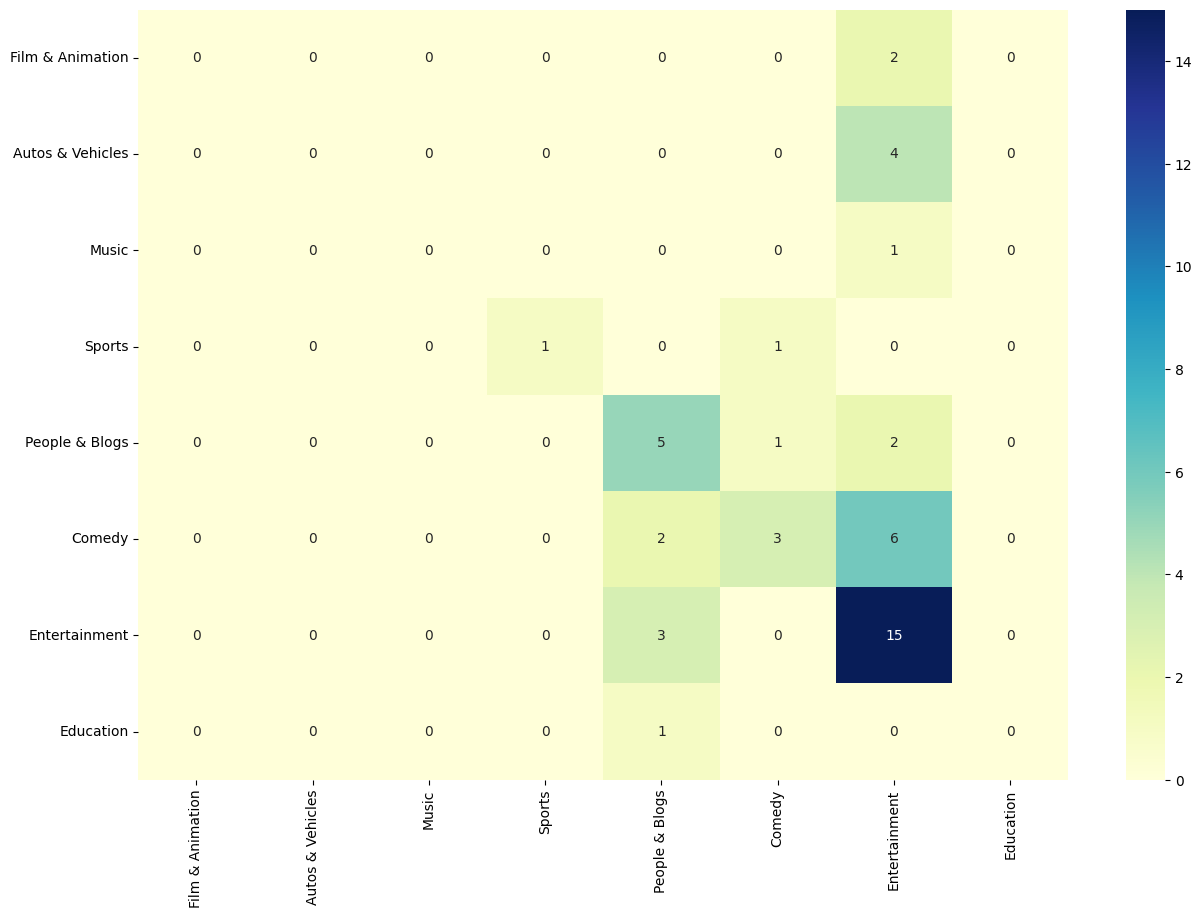

In [87]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sn

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, random_predictions)
conf_matrix_df = pd.DataFrame(conf_matrix, index=target_names, columns=target_names)

plt.figure(figsize=(15, 10))
x = sn.heatmap(conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(), fmt='d', cmap="YlGnBu")
plt.yticks(rotation=0)
plt.xticks(rotation=90)

Throughout the classification report and confusion matrix steps, the results have shown the utilizing a Random Forest Classifier appears to be the best performer with an acuracy of 0.51 and a weighted average F1-score of 0.45. The numbers do seem low and at 50% for accuracy, but this could be from the dataset. With using Superbowl Ads from on youtube, there is a limit on time and amount being utilized, additionally, ranges for type of Ads do effect possible accuracy scores.

## Task 4: Results
Merge dataframes and save into a CSV file

In [89]:
df_output = pd.merge(df, t_df_cleaned, on='index', how='inner')
print(df_output.head(10))

   year      brand                          superbowl_ads_dot_com_url  \
0  2018     Toyota        https://superbowl-ads.com/good-odds-toyota/   
1  2020  Bud Light  https://superbowl-ads.com/2020-bud-light-seltz...   
2  2006  Bud Light  https://superbowl-ads.com/2006-bud-light-bear-...   
3  2018    Hynudai  https://superbowl-ads.com/hope-detector-nfl-su...   
4  2003  Bud Light  https://superbowl-ads.com/2003-bud-light-hermi...   
5  2020     Toyota  https://superbowl-ads.com/2020-toyota-go-place...   
6  2020  Coca-Cola  https://superbowl-ads.com/2020-coca-cola-energ...   
7  2020        Kia  https://superbowl-ads.com/2020-kia-tough-never...   
8  2020    Hynudai  https://superbowl-ads.com/2020-hyundai-smaht-p...   
9  2020  Budweiser  https://superbowl-ads.com/2020-budweiser-typic...   

                                   youtube_url  funny  show_product_quickly  \
0  https://www.youtube.com/watch?v=zeBZvwYQ-hA  False                 False   
1  https://www.youtube.com/watch?v=nbb

In [90]:
df_output.to_csv('predicted_data.csv', index=False)

In [93]:
# Data Preparation
topic_data = []
target_topic_ids = [0, 1, 3, 18]

for topic_id in target_topic_ids:
    # Retrieve the top 10 words and their probabilities for the current topic
    topic_terms = lda_model_20_topics.show_topic(topic_id, topn=10)

    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

df_topic_words = pd.DataFrame(topic_data)

--- Visualizing selected topics from the 20-topic model ---

--- Top 10 Words for Topic 0 from 20-topic model ---


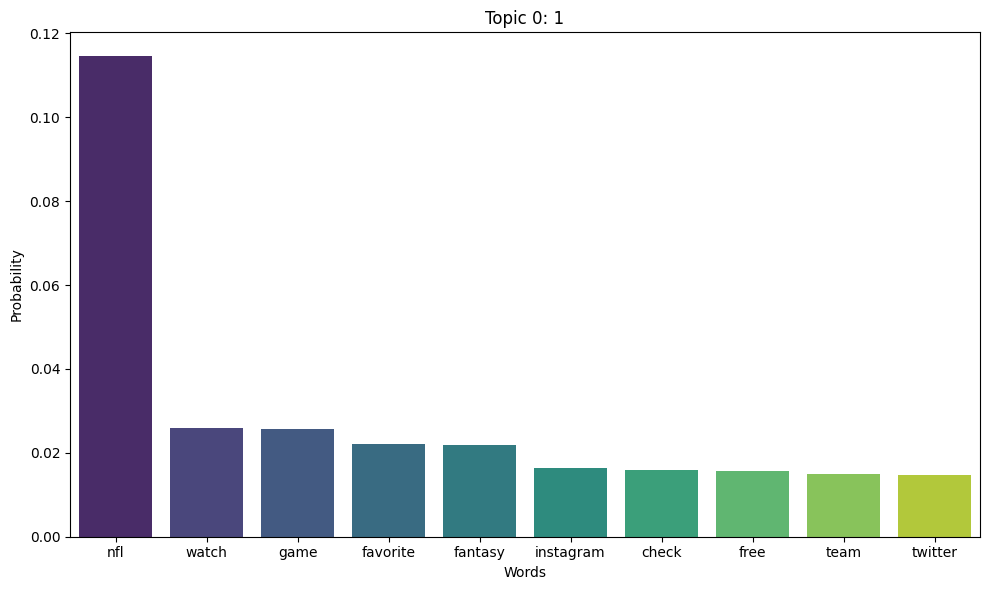


--- Top 10 Words for Topic 1 from 20-topic model ---


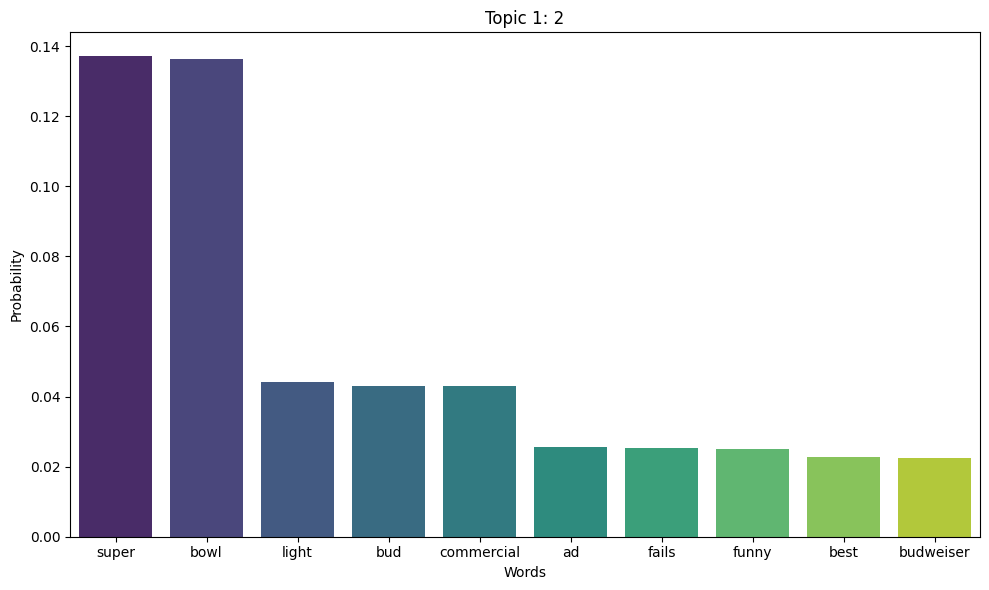


--- Top 10 Words for Topic 3 from 20-topic model ---


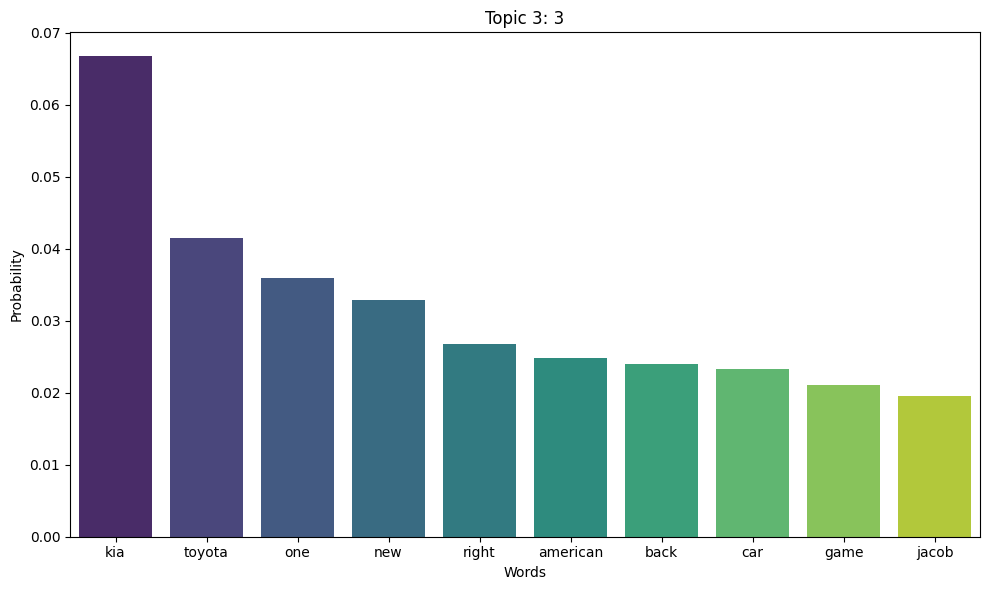


--- Top 10 Words for Topic 18 from 20-topic model ---


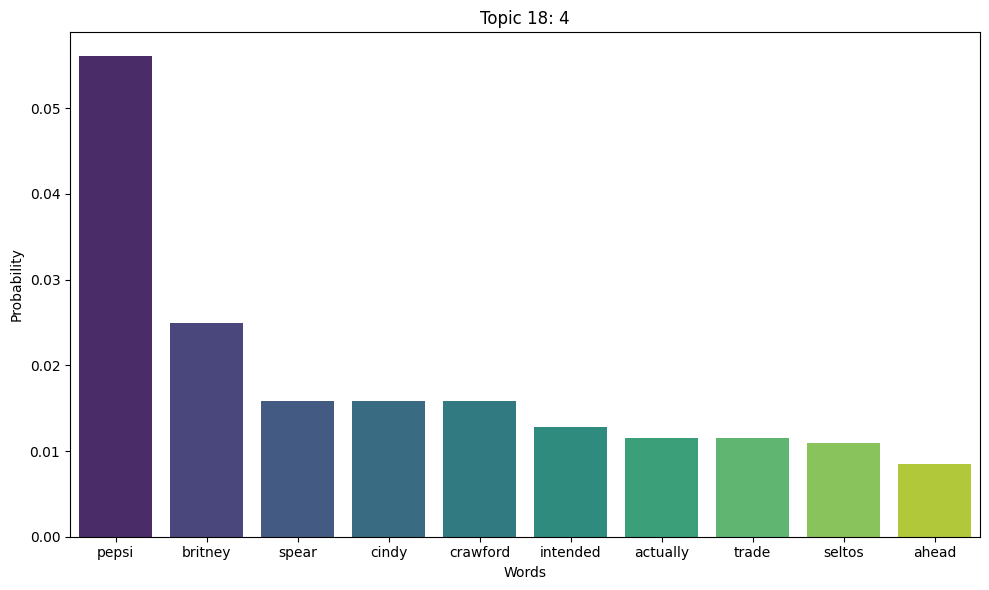

In [94]:
# Function to repeat graph creation
def plot_topic_words_and_label(lda_model, topic_id, dictionary, title, num_words=10):
    print(f"\n--- Top {num_words} Words for Topic {topic_id} from {lda_model.num_topics}-topic model ---")
    top_words = lda_model.show_topic(topic_id, topn=num_words)
    words = [word for word, prob in top_words]
    probabilities = [prob for word, prob in top_words]

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=words, y=probabilities, ax=ax, hue=words, legend=False, palette='viridis')
    ax.set_title(f'Topic {topic_id}: {title}')
    ax.set_xlabel('Words')
    ax.set_ylabel('Probability')
    plt.tight_layout()
    plt.show()

# Visualize topics 5, 10, 15 from the 20-topic model
print("--- Visualizing selected topics from the 20-topic model ---")
plot_topic_words_and_label(lda_model_20_topics, 0, dictionary, '1')
plot_topic_words_and_label(lda_model_20_topics, 1, dictionary, '2')
plot_topic_words_and_label(lda_model_20_topics, 3, dictionary, '3')
plot_topic_words_and_label(lda_model_20_topics, 18, dictionary, '4')

# Generate interactive graphic for all 20 Topics
vis = pyLDAvis.gensim_models.prepare(lda_model_20_topics, corpus, dictionary)
pyLDAvis.display(vis)